In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

company_df = pd.read_csv('company_quarterly_data.csv')
nasscom_df = pd.read_csv('nasscom_sector_data.csv')

print(company_df.shape)        # expect (80, 8) → 5 companies × 16 quarters
print(company_df.dtypes)       # check if numbers are being read as strings
print(company_df.isna().sum()) # find any missing values before they surprise you later


(80, 8)
company              object
fiscal_quarter       object
quarter_end_date     object
revenue_inr_cr        int64
revenue_usd_mn      float64
headcount             int64
source_doc           object
source_url           object
dtype: object
company             0
fiscal_quarter      0
quarter_end_date    0
revenue_inr_cr      0
revenue_usd_mn      0
headcount           0
source_doc          0
source_url          0
dtype: int64


In [9]:
#datatype

company_df['quarter_end_date'] = pd.to_datetime(company_df['quarter_end_date'])

for col in ['revenue_inr_cr', 'revenue_usd_mn', 'headcount']:
    company_df[col] = pd.to_numeric(company_df[col], errors='coerce')

company_df = company_df.sort_values(['company', 'quarter_end_date']).reset_index(drop=True)

print(company_df.dtypes)   # confirm quarter_end_date is now datetime64
company_df.head()

company                     object
fiscal_quarter              object
quarter_end_date    datetime64[ns]
revenue_inr_cr               int64
revenue_usd_mn             float64
headcount                    int64
source_doc                  object
source_url                  object
dtype: object


,company,fiscal_quarter,quarter_end_date,revenue_inr_cr,revenue_usd_mn,headcount,source_doc,source_url
0,HCLTech,Q1 FY22,2021-06-30,20068,2720.0,176499,HCLTech Q1 FY22 Financial Results,https://www.hcltech.com/investors/results-reports
1,HCLTech,Q2 FY22,2021-09-30,20655,2790.0,187634,HCLTech Q2 FY22 Financial Results,https://www.hcltech.com/investors/results-reports
2,HCLTech,Q3 FY22,2021-12-31,22331,2977.0,197777,HCLTech Q3 FY22 Financial Results,https://www.hcltech.com/investors/results-reports
3,HCLTech,Q4 FY22,2022-03-31,22597,2993.0,208877,HCLTech Q4 FY22 Financial Results,https://www.hcltech.com/investors/results-reports
4,HCLTech,Q1 FY23,2022-06-30,23464,3025.0,210966,HCLTech Q1 FY23 Financial Results,https://www.hcltech.com/investors/results-reports


In [10]:
# Step 3: Validation Checks — catch bad data before it corrupts your analysis

# Check for duplicate company-quarter rows (e.g. same company, same date appearing twice)
# If this isn't 0, your later sums/aggregations will double-count that row
dupes = company_df.duplicated(subset=['company', 'quarter_end_date']).sum()
print("Duplicate company-quarter rows:", dupes)

# Check for non-positive revenue — a 0 or negative revenue almost always means a scraping/data entry error
bad_revenue = (company_df['revenue_inr_cr'].dropna() <= 0).sum()
print("Non-positive revenue rows:", bad_revenue)

# Same check for headcount — a company can't have 0 or negative employees
bad_headcount = (company_df['headcount'].dropna() <= 0).sum()
print("Non-positive headcount rows:", bad_headcount)

# Check each company has exactly 16 rows (16 quarters) — flags if any company is missing a quarter
print(company_df.groupby('company').size())

Duplicate company-quarter rows: 0
Non-positive revenue rows: 0
Non-positive headcount rows: 0
company
HCLTech          16
Infosys          16
TCS              16
Tech Mahindra    16
Wipro            16
dtype: int64


In [11]:
# Step 4: Company-Level Feature Engineering — build the core productivity metric

# revenue_inr_cr is in ₹ Crore. 1 Crore = 100 Lakh.
# So: revenue_inr_cr * 100 = revenue in Lakh, then divide by headcount = ₹ Lakh revenue generated PER EMPLOYEE that quarter
company_df['rev_per_employee_inr_lakh'] = company_df['revenue_inr_cr'] * 100 / company_df['headcount']

# Quarter-over-quarter % change in revenue, per company
# groupby('company') is critical here — without it, pandas would calculate "growth" across company boundaries
# (e.g. comparing TCS's last quarter to Infosys's first quarter, which is meaningless)
company_df['revenue_qoq_pct'] = company_df.groupby('company')['revenue_inr_cr'].pct_change() * 100

# Same idea, but for headcount growth
company_df['headcount_qoq_pct'] = company_df.groupby('company')['headcount'].pct_change() * 100

# And for our main productivity metric — this tells us if productivity is rising or falling quarter to quarter
company_df['rev_per_emp_qoq_pct'] = company_df.groupby('company')['rev_per_employee_inr_lakh'].pct_change() * 100

# Preview to sanity check the numbers look reasonable
company_df[['company', 'quarter_end_date', 'rev_per_employee_inr_lakh', 'revenue_qoq_pct', 'headcount_qoq_pct']].head(10)

,company,quarter_end_date,rev_per_employee_inr_lakh,revenue_qoq_pct,headcount_qoq_pct
0,HCLTech,2021-06-30,11.370036,NaN,NaN
1,HCLTech,2021-09-30,11.008133,2.925055,6.308818
2,HCLTech,2021-12-31,11.290999,8.114258,5.405737
3,HCLTech,2022-03-31,10.818328,1.191169,5.612382
4,HCLTech,2022-06-30,11.122171,3.836792,1.000110
5,HCLTech,2022-09-30,11.255443,5.207978,3.962250
6,HCLTech,2022-12-31,12.012417,8.158470,1.342756
7,HCLTech,2023-03-31,11.775484,-0.352060,1.652945
8,HCLTech,2023-06-30,11.768813,-1.165151,-1.109124
9,HCLTech,2023-09-30,12.061192,1.429875,-1.028921


In [12]:
# Step 5: Sector-Level Aggregation — combine all 5 companies into one "sector" view per quarter

# For each quarter_end_date, sum up revenue and headcount ACROSS all 5 companies
# This treats the 5 companies together as one proxy for "the sector"
sector_df = company_df.groupby('quarter_end_date').agg(
    total_revenue_inr_cr=('revenue_inr_cr', 'sum'),
    total_headcount=('headcount', 'sum')
).reset_index()

# Same productivity formula as before, but now at the sector level instead of per-company
sector_df['sector_rev_per_employee_inr_lakh'] = sector_df['total_revenue_inr_cr'] * 100 / sector_df['total_headcount']

# Preview — this should have exactly 16 rows (one per quarter), not 80
print(sector_df.shape)
sector_df.head()

(16, 4)


,quarter_end_date,total_revenue_inr_cr,total_headcount,sector_rev_per_employee_inr_lakh
0,2021-06-30,121823,1289663,9.446111
1,2021-09-30,127675,1358557,9.397839
2,2021-12-31,134844,1423568,9.472256
3,2022-03-31,138440,1509388,9.171929
4,2022-06-30,144930,1569092,9.236552


In [13]:
# Step 6: Indexed Growth — put revenue and headcount on the SAME scale so we can compare them on one chart

# Take the very first quarter's values as our "starting point" (index = 100)
base_rev = sector_df['total_revenue_inr_cr'].iloc[0]
base_hc = sector_df['total_headcount'].iloc[0]

# Convert every quarter's revenue into "% of starting revenue" — e.g. 112 means revenue is now 12% higher than Q1 FY22
sector_df['revenue_index'] = sector_df['total_revenue_inr_cr'] / base_rev * 100

# Same idea for headcount
sector_df['headcount_index'] = sector_df['total_headcount'] / base_hc * 100

# The gap between these two lines IS the "decoupling" — the bigger this number, the more revenue is outpacing headcount
sector_df['decoupling_gap'] = sector_df['revenue_index'] - sector_df['headcount_index']

# Preview
sector_df[['quarter_end_date', 'revenue_index', 'headcount_index', 'decoupling_gap']]

,quarter_end_date,revenue_index,headcount_index,decoupling_gap
0,2021-06-30,100.000000,100.000000,0.000000
1,2021-09-30,104.803691,105.342016,-0.538325
2,2021-12-31,110.688458,110.382945,0.305513
3,2022-03-31,113.640281,117.037397,-3.397115
4,2022-06-30,118.967683,121.666823,-2.699140
5,2022-09-30,124.936999,124.358456,0.578542
6,2022-12-31,131.512112,123.978202,7.533910
7,2023-03-31,131.434130,123.543437,7.890693
8,2023-06-30,131.008923,121.977990,9.030933
9,2023-09-30,131.947169,120.512025,11.435144


What the data is showing:

2021-2022 (rows 0-4): the gap is negative or near-zero. Headcount actually grew faster than revenue for a while (index 121.6 vs 118.9 by mid-2022) — this was the post-COVID hiring boom, when IT companies were hiring aggressively.
From late-2022 onward, the gap flips positive and keeps climbing every quarter — 0.58 → 7.5 → 9.0 → 14.7 → 21.6 by March 2025.
Headcount index actually peaks around 124 (Sept 2022) and then declines to 119 while revenue keeps climbing to 140.8.

In [14]:
# Step 7: Headline Metrics — the actual numbers you'll say out loud in an interview

# Total % growth in revenue and headcount from Q1 FY22 to the latest quarter (since index started at 100)
total_rev_growth = sector_df['revenue_index'].iloc[-1] - 100
total_hc_growth = sector_df['headcount_index'].iloc[-1] - 100

# How many times faster did revenue grow compared to headcount?
multiplier = total_rev_growth / total_hc_growth

# Revenue-per-employee: where it started vs where it ended, and the % increase
start_rpe = sector_df['sector_rev_per_employee_inr_lakh'].iloc[0]
end_rpe = sector_df['sector_rev_per_employee_inr_lakh'].iloc[-1]

print(f"Revenue grew {total_rev_growth:.1f}% over 16 quarters")
print(f"Headcount grew {total_hc_growth:.1f}% over 16 quarters")
print(f"Revenue grew {multiplier:.1f}x faster than headcount")
print(f"Revenue-per-employee: Rs {start_rpe:.2f} Lakh -> Rs {end_rpe:.2f} Lakh ({(end_rpe/start_rpe - 1)*100:.1f}% increase)")

Revenue grew 40.8% over 16 quarters
Headcount grew 19.2% over 16 quarters
Revenue grew 2.1x faster than headcount
Revenue-per-employee: Rs 9.45 Lakh -> Rs 11.16 Lakh (18.1% increase)


In [15]:
# Step 8: NASSCOM Cross-Validation — prove your 5-company sample isn't a cherry-picked outlier

# This function converts a date into its Indian Fiscal Year label (e.g. "FY23")
# Indian fiscal year runs April to March, so:
#   - if the month is Jan/Feb/Mar, the fiscal year "ends" in that same calendar year
#   - if the month is Apr-Dec, the fiscal year "ends" in the NEXT calendar year
def get_fiscal_year(date):
    fy_end = date.year if date.month <= 3 else date.year + 1
    return f"FY{str(fy_end)[-2:]}"

# Apply this function to every row so each quarter gets tagged with its fiscal year
company_df['fiscal_year'] = company_df['quarter_end_date'].apply(get_fiscal_year)

# Now group by fiscal year: sum revenue across all 4 quarters + all 5 companies,
# and take the average headcount across the year (headcount is a snapshot, not something you "sum")
fy_agg = company_df.groupby('fiscal_year').agg(
    sample_revenue_inr_cr=('revenue_inr_cr', 'sum'),
    sample_avg_headcount=('headcount', 'mean')
).reset_index()

# Merge your 5-company yearly totals with NASSCOM's official sector-wide annual numbers
# 'inner' join means we only keep years that exist in BOTH datasets
comparison = fy_agg.merge(nasscom_df, left_on='fiscal_year', right_on='year', how='inner')

# Show the comparison — does the direction/pattern match NASSCOM's official growth %?
print(comparison[['fiscal_year', 'sample_revenue_inr_cr', 'sample_avg_headcount', 
                   'revenue_growth_pct', 'employment_growth_pct']])

  fiscal_year  sample_revenue_inr_cr  sample_avg_headcount  \
0        FY23                 617461             318254.60   
1        FY24                 646242             309514.40   
2        FY25                 677437             306639.95   

   revenue_growth_pct  employment_growth_pct  
0                 8.4                    5.7  
1                 3.8                    1.1  
2                 5.1                    2.3  


In [16]:
# Sample ke apne headcount ka saal-dar-saal % change nikalo (NASSCOM se compare karne ke bajay)
fy_agg['sample_headcount_yoy_pct'] = fy_agg['sample_avg_headcount'].pct_change() * 100
print(fy_agg[['fiscal_year', 'sample_avg_headcount', 'sample_headcount_yoy_pct']])

  fiscal_year  sample_avg_headcount  sample_headcount_yoy_pct
0        FY22             279058.80                       NaN
1        FY23             318254.60                 14.045714
2        FY24             309514.40                 -2.746292
3        FY25             306639.95                 -0.928697


Data visualization

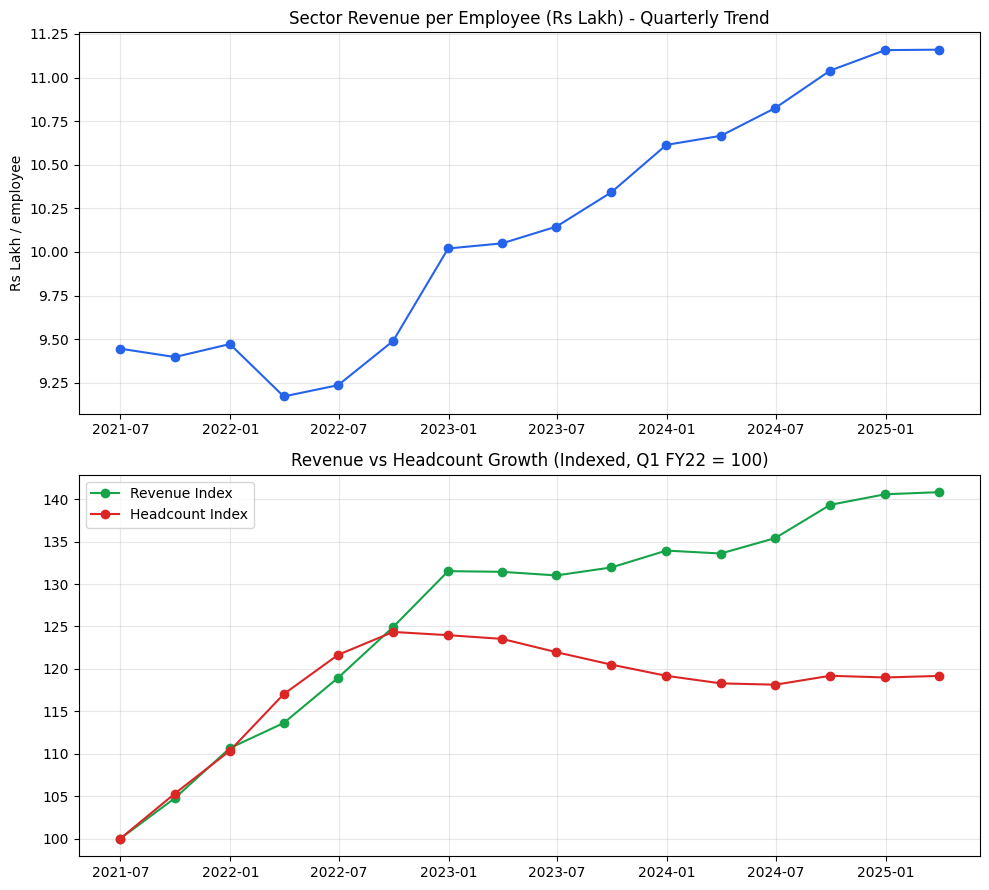

In [17]:
# Step 9: Visualization — turn the numbers into charts you can actually show in your resume/interview

import matplotlib.pyplot as plt

# Create 2 charts stacked on top of each other (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# CHART 1: Revenue per employee trend, quarter by quarter
# This shows the raw productivity metric climbing (or not) over time
axes[0].plot(sector_df['quarter_end_date'], sector_df['sector_rev_per_employee_inr_lakh'], 
             marker='o', color='#2563eb')
axes[0].set_title('Sector Revenue per Employee (Rs Lakh) - Quarterly Trend')
axes[0].set_ylabel('Rs Lakh / employee')
axes[0].grid(alpha=0.3)  # light grid lines make it easier to read values

# CHART 2: Revenue index vs Headcount index, both on the same scale
# This is the "decoupling" chart — the gap between the two lines IS your story
axes[1].plot(sector_df['quarter_end_date'], sector_df['revenue_index'], 
             marker='o', label='Revenue Index', color='#16a34a')
axes[1].plot(sector_df['quarter_end_date'], sector_df['headcount_index'], 
             marker='o', label='Headcount Index', color='#dc2626')
axes[1].set_title('Revenue vs Headcount Growth (Indexed, Q1 FY22 = 100)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Adjust spacing so titles/labels don't overlap
plt.tight_layout()

# Save the chart as an image file so you can drop it straight into your resume/PPT/report
plt.savefig('revenue_headcount_decoupling.png', dpi=150)

# Display it right here in the notebook
plt.show()

In [18]:
# Step 10: Export clean data for Power BI — Python's job ends here

# Company-level cleaned data (80 rows) — for company-wise comparisons in the dashboard
company_df.to_csv('company_level_clean.csv', index=False)

# Sector-level quarterly summary (16 rows) — this drives your MAIN headline chart
sector_df.to_csv('sector_quarterly_summary.csv', index=False)

# NASSCOM comparison (3 rows) — for the "our sample matches the sector" validation slide
comparison.to_csv('nasscom_comparison.csv', index=False)

# Confirm all 3 files saved successfully
print("Exported: company_level_clean.csv, sector_quarterly_summary.csv, nasscom_comparison.csv")

Exported: company_level_clean.csv, sector_quarterly_summary.csv, nasscom_comparison.csv


CURRENCY CHECK

In [19]:
# Currency Check — same analysis but on USD revenue, jo currency-effect se free hai

# Sector-level USD revenue ko bhi sum karo (jaise humne INR ke liye kiya tha)
sector_df_usd = company_df.groupby('quarter_end_date').agg(
    total_revenue_usd_mn=('revenue_usd_mn', 'sum')
).reset_index()

# Same indexing logic — Q1 FY22 ko 100 maan ke baaki sab uske relative dikhao
base_rev_usd = sector_df_usd['total_revenue_usd_mn'].iloc[0]
sector_df_usd['revenue_index_usd'] = sector_df_usd['total_revenue_usd_mn'] / base_rev_usd * 100

# Compare karo: INR wali growth vs USD wali growth
total_rev_growth_inr = sector_df['revenue_index'].iloc[-1] - 100
total_rev_growth_usd = sector_df_usd['revenue_index_usd'].iloc[-1] - 100

print(f"Revenue growth in INR terms: {total_rev_growth_inr:.1f}%")
print(f"Revenue growth in USD terms: {total_rev_growth_usd:.1f}%")
print(f"Currency effect contributed: {total_rev_growth_inr - total_rev_growth_usd:.1f} percentage points")

Revenue growth in INR terms: 40.8%
Revenue growth in USD terms: 20.6%
Currency effect contributed: 20.2 percentage points


In [20]:
# Step 11: Currency-Adjusted Re-Analysis — check if the decoupling story holds up in real (USD) terms

# Merge USD revenue data with headcount data so we can calculate USD-based revenue per employee
sector_df_usd = sector_df_usd.merge(
    sector_df[['quarter_end_date', 'total_headcount', 'headcount_index']], 
    on='quarter_end_date'
)

# Revenue per employee in USD (revenue_usd_mn is in $ Million, so *1e6 converts to $, then divide by headcount)
sector_df_usd['rev_per_employee_usd'] = sector_df_usd['total_revenue_usd_mn'] * 1e6 / sector_df_usd['total_headcount']

# Recalculate the headline comparison using REAL (currency-neutral) revenue growth instead of INR
real_rev_growth = sector_df_usd['revenue_index_usd'].iloc[-1] - 100
real_hc_growth = sector_df['headcount_index'].iloc[-1] - 100
real_multiplier = real_rev_growth / real_hc_growth

# Print both versions side by side so the difference is completely transparent
print("--- COMPARISON: INR (nominal) vs USD (real) ---")
print(f"INR revenue growth: {total_rev_growth_inr:.1f}%  |  Headcount growth: {real_hc_growth:.1f}%  |  Multiplier: {total_rev_growth_inr/real_hc_growth:.2f}x")
print(f"USD revenue growth: {real_rev_growth:.1f}%  |  Headcount growth: {real_hc_growth:.1f}%  |  Multiplier: {real_multiplier:.2f}x")

# Show the quarter-by-quarter USD revenue-per-employee trend — this is the TRUE productivity trend, free of currency noise
print("\n--- Real (USD-based) Revenue per Employee, Quarterly ---")
print(sector_df_usd[['quarter_end_date', 'rev_per_employee_usd']])

--- COMPARISON: INR (nominal) vs USD (real) ---
INR revenue growth: 40.8%  |  Headcount growth: 19.2%  |  Multiplier: 2.13x
USD revenue growth: 20.6%  |  Headcount growth: 19.2%  |  Multiplier: 1.07x

--- Real (USD-based) Revenue per Employee, Quarterly ---
   quarter_end_date  rev_per_employee_usd
0        2021-06-30          12758.449300
1        2021-09-30          12641.059595
2        2021-12-31          12591.038854
3        2022-03-31          12123.324155
4        2022-06-30          11864.505077
5        2022-09-30          11815.463850
6        2022-12-31          12164.292849
7        2023-03-31          12223.105089
8        2023-06-30          12346.601149
9        2023-09-30          12496.018850
10       2023-12-31          12742.647709
11       2024-03-31          12821.279139
12       2024-06-30          12973.259253
13       2024-09-30          13177.757034
14       2024-12-31          13166.739210
15       2025-03-31          12906.833462


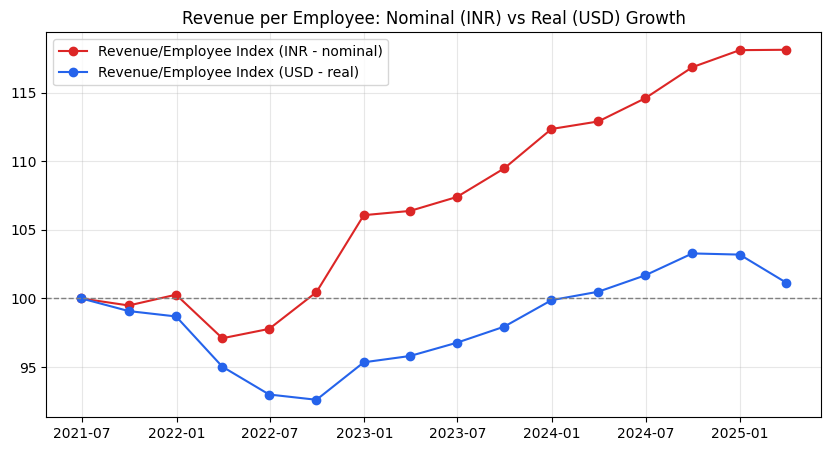

In [21]:
# Step 12: Compare INR-based vs USD-based revenue-per-employee index side by side
# This chart visually proves how much of the "productivity story" was currency-driven

# Index the USD revenue-per-employee the same way we did for INR (Q1 FY22 = 100)
base_rpe_usd = sector_df_usd['rev_per_employee_usd'].iloc[0]
sector_df_usd['rpe_index_usd'] = sector_df_usd['rev_per_employee_usd'] / base_rpe_usd * 100

# Do the same for the INR-based revenue-per-employee, for direct comparison
base_rpe_inr = sector_df['sector_rev_per_employee_inr_lakh'].iloc[0]
sector_df['rpe_index_inr'] = sector_df['sector_rev_per_employee_inr_lakh'] / base_rpe_inr * 100

# Plot both on the same chart — the gap between them IS the currency effect
plt.figure(figsize=(10, 5))
plt.plot(sector_df['quarter_end_date'], sector_df['rpe_index_inr'], marker='o', label='Revenue/Employee Index (INR - nominal)', color='#dc2626')
plt.plot(sector_df_usd['quarter_end_date'], sector_df_usd['rpe_index_usd'], marker='o', label='Revenue/Employee Index (USD - real)', color='#2563eb')
plt.axhline(100, color='gray', linestyle='--', linewidth=1)  # reference line showing "no change from start"
plt.title('Revenue per Employee: Nominal (INR) vs Real (USD) Growth')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('currency_adjusted_productivity.png', dpi=150)
plt.show()

In [22]:
# Load the exported CSVs into a SQLite database (lightweight, no server needed)
import sqlite3

conn = sqlite3.connect('it_sector_analysis.db')

# Push each cleaned DataFrame into its own SQL table
company_df.to_sql('company_quarterly', conn, if_exists='replace', index=False)
sector_df.to_sql('sector_quarterly', conn, if_exists='replace', index=False)
comparison.to_sql('nasscom_comparison', conn, if_exists='replace', index=False)

print("Database created: it_sector_analysis.db with 3 tables")

Database created: it_sector_analysis.db with 3 tables


In [24]:
# Query 1: Rank companies by productivity growth (start vs latest revenue-per-employee)
query1 = """
SELECT company,
       MIN(rev_per_employee_inr_lakh) AS start_rpe,
       MAX(quarter_end_date) AS latest_qtr,
       ROUND((MAX(rev_per_employee_inr_lakh) - MIN(rev_per_employee_inr_lakh)) 
             / MIN(rev_per_employee_inr_lakh) * 100, 2) AS pct_growth
FROM company_quarterly
GROUP BY company
ORDER BY pct_growth DESC;
"""
print(pd.read_sql(query1, conn))

# Query 2: Sector-wide quarterly trend (revenue, headcount, productivity together)
query2 = """
SELECT quarter_end_date, total_revenue_inr_cr, total_headcount, 
       sector_rev_per_employee_inr_lakh
FROM sector_quarterly
ORDER BY quarter_end_date;
"""
print(pd.read_sql(query2, conn))

         company  start_rpe           latest_qtr  pct_growth
0        Infosys  10.278490  2025-03-31 00:00:00       25.65
1        HCLTech  10.818328  2025-03-31 00:00:00       25.16
2            TCS   8.542963  2025-03-31 00:00:00       24.14
3  Tech Mahindra   7.706473  2025-03-31 00:00:00       16.80
4          Wipro   8.326437  2025-03-31 00:00:00       15.80
       quarter_end_date  total_revenue_inr_cr  total_headcount  \
0   2021-06-30 00:00:00                121823          1289663   
1   2021-09-30 00:00:00                127675          1358557   
2   2021-12-31 00:00:00                134844          1423568   
3   2022-03-31 00:00:00                138440          1509388   
4   2022-06-30 00:00:00                144930          1569092   
5   2022-09-30 00:00:00                152202          1603805   
6   2022-12-31 00:00:00                160212          1598901   
7   2023-03-31 00:00:00                160117          1593294   
8   2023-06-30 00:00:00                1

In [25]:
# Insight 1: Company-level REAL (USD) productivity growth — who actually improved vs who declined
query3 = """
SELECT company,
       ROUND(MIN(revenue_usd_mn), 1) AS start_rev_usd,
       ROUND(MAX(revenue_usd_mn), 1) AS end_rev_usd,
       MIN(headcount) AS start_hc,
       MAX(headcount) AS end_hc
FROM company_quarterly
GROUP BY company;
"""
company_summary = pd.read_sql(query3, conn)

# Calculate each company's own USD revenue-per-employee change (start vs end quarter)
company_summary['start_rpe_usd'] = company_summary['start_rev_usd'] * 1e6 / company_summary['start_hc']
company_summary['end_rpe_usd'] = company_summary['end_rev_usd'] * 1e6 / company_summary['end_hc']
company_summary['real_productivity_change_pct'] = (
    (company_summary['end_rpe_usd'] - company_summary['start_rpe_usd']) / company_summary['start_rpe_usd'] * 100
)
company_summary['headcount_change_pct'] = (
    (company_summary['end_hc'] - company_summary['start_hc']) / company_summary['start_hc'] * 100
)

print(company_summary[['company', 'real_productivity_change_pct', 'headcount_change_pct']])

# Insight 2: Correlation — did companies that cut headcount MORE see BIGGER productivity gains?
correlation = company_summary['headcount_change_pct'].corr(company_summary['real_productivity_change_pct'])
print(f"\nCorrelation (headcount change vs productivity change): {correlation:.2f}")

         company  real_productivity_change_pct  headcount_change_pct
0        HCLTech                      0.779420             28.885149
1        Infosys                      0.888273             29.442477
2            TCS                      2.968381             21.041414
3  Tech Mahindra                     -7.135260             29.817920
4          Wipro                     -5.316216             23.483253

Correlation (headcount change vs productivity change): -0.27


In [26]:
# Export final datasets for Power BI import
company_df.to_csv('company_level_clean.csv', index=False)
sector_df.to_csv('sector_quarterly_summary.csv', index=False)
sector_df_usd.to_csv('sector_quarterly_usd.csv', index=False)
comparison.to_csv('nasscom_comparison.csv', index=False)
company_summary.to_csv('company_productivity_summary.csv', index=False)

print("5 files ready for Power BI import")

5 files ready for Power BI import
